In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('US_Accidents_March23.csv')
print('The Dataset contains:\nRows: {:,d}\nColumns: {}'.format(df.shape[0], df.shape[1]))

The Dataset contains:
Rows: 7,728,394
Columns: 46


In [3]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

## Sources

In [4]:
df_source = df.groupby(['Severity','Source']).size().reset_index().rename(
    columns = {
        0:'Cases'
    }
).pivot(
    columns='Severity',
    index = 'Source',
    values = 'Cases'
)

df_source.head()

Severity,1,2,3,4
Source,,,,
Source1,28206,3945613,161528,190285
Source2,35060,2148978,1107062,14273
Source3,4100,62390,30747,152


<Axes: xlabel='Source'>

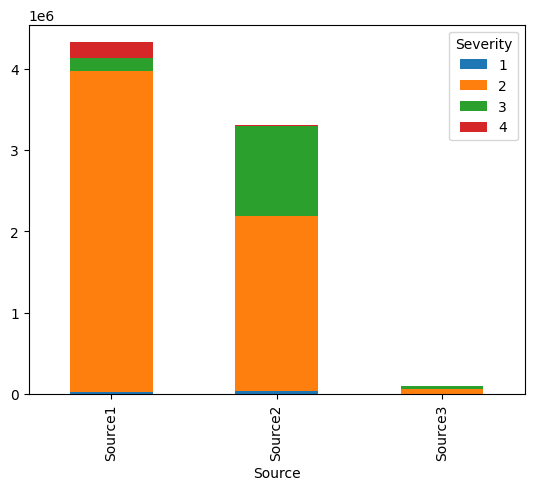

In [5]:
df_source.plot(
    kind = 'bar',
    stacked = True
)

In [6]:
df_percent = round(df_source.div(df_source.sum(axis = 1), axis=0) *100, 2)
df_percent.loc['TotalPer'] = round(df_source.sum(axis = 0) / df.shape[0] * 100,2)
df_percent = df_percent.assign(TotalPer = round(df_source.sum(axis=1) / df.shape[0] * 100,2))
df_percent

Severity,1,2,3,4,TotalPer
Source,,,,,
Source1,0.65,91.21,3.73,4.40,55.97
Source2,1.06,65.01,33.49,0.43,42.77
Source3,4.21,64.06,31.57,0.16,1.26
TotalPer,0.87,79.67,16.81,2.65,NaN


<Axes: xlabel='Severity', ylabel='Source'>

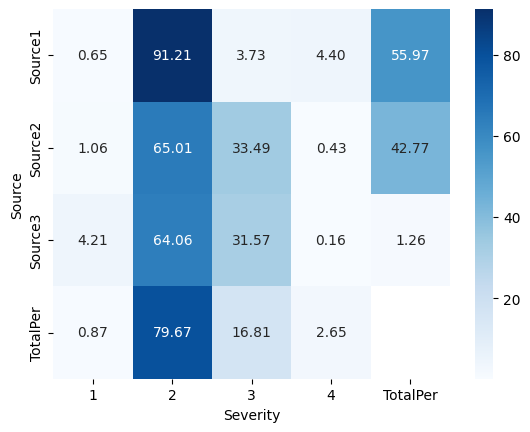

In [7]:
plt.Figure(figsize = (10,6))
sns.heatmap(
    data = df_percent,
    annot = True,
    fmt = '.2f',
    cmap = 'Blues'
)

## City

In [8]:
df.City.unique()

<StringArray>
[                      'Dayton',                 'Reynoldsburg',
                 'Williamsburg',                  'Westerville',
                     'Columbus',                   'Miamisburg',
                    'Johnstown',                       'Dublin',
             'Canal Winchester',                      'Lebanon',
 ...
                      'Leadore',                   'Vallecitos',
                    'Guildhall',              'Sandy River Plt',
                       'Lublin',                     'Fairbank',
                    'Pond Eddy',                    'Ness City',
                   'Clarksdale', 'American Fork-Pleasant Grove']
Length: 13679, dtype: str

In [9]:
df.City.nunique()

13678

In [10]:
city_df = pd.DataFrame(df.City.value_counts()).reset_index().rename(columns = {'count':'Cases'})
city_df.head(10)

,City,Cases
0,Miami,186917
1,Houston,169609
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
5,Orlando,109733
6,Austin,97359
7,Raleigh,86079
8,Nashville,72930
9,Baton Rouge,71588


<Axes: title={'center': 'Top 10 cities with the most cases'}, xlabel='City'>

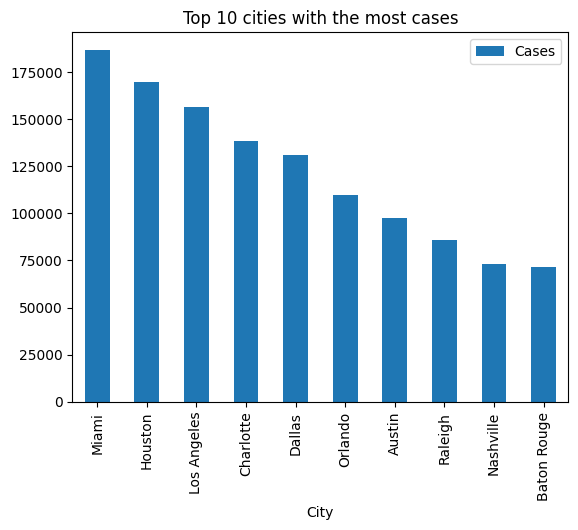

In [11]:
city_df.head(10).plot(
    kind = "bar",
    x = 'City',
    y = 'Cases',
    title = 'Top 10 cities with the most cases'
    )

In [12]:
total = sum(city_df.Cases)
total10 = sum(city_df.Cases.head(10)) / total * 100
round(total10,2)

15.79

In [13]:
for i in city_df.head(10).Cases:
    result = round(i / sum(city_df.Cases) * 100, 2)
    print(result)

2.42
2.19
2.02
1.79
1.69
1.42
1.26
1.11
0.94
0.93


#### Top 10 city accounted for 15.79% of all accidents.
top 1: Miami accounted for 2.42% of all accidents

In [14]:
print(round(sum(city_df.Cases)/7))
print(round(sum(city_df.Cases)/(7*365)))
print(round(city_df.Cases[0]/7))
print(round(city_df.Cases[0]/(7*365)))

1104020
3025
26702
73


In [15]:
round(3025/24)
round(73/2)

36

<p>Average in 7 years time, America have 1,104,020 accident cases every year
<p>About 126 accidents happen every hour in US
<p>In Miami, 26,702 accidents happen yearly
<p>About 36 accidents happen every 12 hours

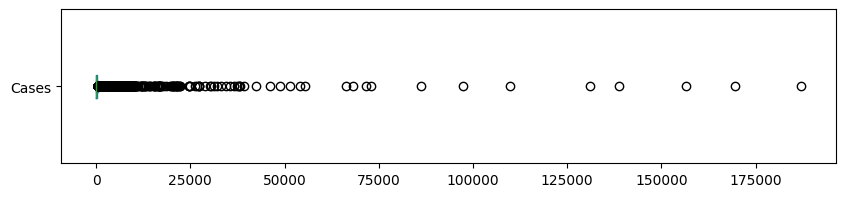

In [16]:
city_df.Cases.plot(kind = 'box', vert = False, figsize=(10,2))
plt.show()

In [17]:
city_df.Cases.describe()

count     13678.000000
mean        565.005191
std        4147.357347
min           1.000000
25%           6.000000
50%          35.000000
75%         201.000000
max      186917.000000
Name: Cases, dtype: float64

In [18]:
def percentage(value,operator):
    if operator == '=':
        result = city_df[city_df.Cases == value].shape[0]
    elif operator == '<':
        result = city_df[city_df.Cases < value].shape[0]
    elif operator ==  '>':
        result = city_df[city_df.Cases > value].shape[0]
    print(f'{result} Cities, {round((result / city_df.shape[0])*100, 2)}%')

percentage(1, '=')
percentage(202, '<')
percentage(1000, '<')
percentage(1000, '>')
percentage(5000, '>')
percentage(10000, '>')

1023 Cities, 7.48%
10265 Cities, 75.05%
12460 Cities, 91.1%
1215 Cities, 8.88%
231 Cities, 1.69%
105 Cities, 0.77%


<p>There are 1023 Cities with one 1 accident in 7 years span
<p>75% (10,265 cities) of all cities has less than 202 accident cases
<p>91.1% (12,460 cities) of all cities has less than 1000 accident cases
<p>8.88% (1215 cities) of all cities has more than 1000 accident cases
<p>1.69% (231 cities) of all cities has more than 5000 accident cases
<p>0.77% (105 cities) of all cities has more than 10000 accident cases

## Severity

In [19]:
severity_df = pd.DataFrame(df.Severity.value_counts())
severity_df = severity_df.rename(columns={'count': 'Cases'})
severity_df.head()

,Cases
Severity,
2,6156981
3,1299337
4,204710
1,67366


<Axes: >

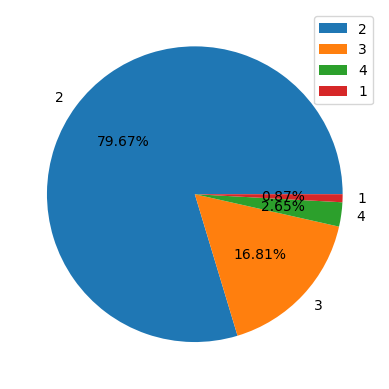

In [20]:
severity_df.plot(
    kind = 'pie',
    y = 'Cases',
    autopct = '%1.2f%%'
)

<p>79.67% of accident cases was moderate (severity 2)
<p>2.65% of accident cases was severe (severity 4)

## Time

In [12]:
df.Start_Time = pd.to_datetime(
    df.Start_Time,
    errors='coerce'
    )

df.End_Time = pd.to_datetime(
    df.End_Time,
    errors='coerce'
    )

In [22]:
dur_df = pd.DataFrame((df.End_Time - df.Start_Time).value_counts(ascending=False)).reset_index().rename(columns={'index':'Duration'})
dur_df.head()

,Duration,count
0,0 days 06:00:00,368393
1,0 days 00:30:00,113699
2,0 days 00:45:00,68175
3,0 days 01:00:00,57672
4,0 days 04:00:00,56867


In [23]:
dur_df['Duration_clean'] = (dur_df['Duration'].astype(str).str[-8:])

In [24]:
dur_df.Duration_clean.unique()

<StringArray>
['06:00:00', '00:30:00', '00:45:00', '01:00:00', '04:00:00', '00:29:45',
 '00:29:46', '00:29:47', '00:29:44', '00:29:43',
 ...
 '19:04:10', '13:01:45', '18:59:50', '16:59:47', '23:43:52', '18:51:45',
 '21:50:49', '17:50:12', '21:59:49', '20:59:59']
Length: 60121, dtype: str

<Axes: title={'center': 'Most impacted durations on the Traffic flow due to the Accidents'}, xlabel='Duration_clean'>

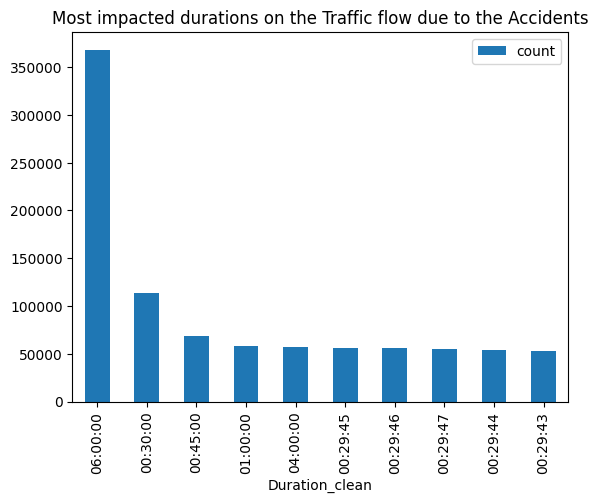

In [25]:
dur_df.head(10).plot(
    kind = 'bar',
    x = 'Duration_clean',
    y = 'count',
    title = 'Most impacted durations on the Traffic flow due to the Accidents'
)

In [26]:
# round(dur_df['count'][0] *100 / sum(dur_df['count']),2)
round(dur_df['count'][0] *100 / df.shape[0],2)

np.float64(4.77)

The majority of road accidents (4.78%) impacted on the traffic flow for 6 hours

## Year

In [27]:
year_df = pd.DataFrame(df.Start_Time.dt.year.value_counts()).reset_index().rename(columns = {'Start_Time':'Year','count':'Cases'}).sort_values(by = 'Year', ascending = True)
year_df.head(7)

,Year,Cases
6,2016.0,410821
5,2017.0,717290
4,2018.0,893426
3,2019.0,954302
2,2020.0,1161598
0,2021.0,1412433
1,2022.0,1268806


<Axes: title={'center': 'Road accident over the years (2016 - 2023)'}, xlabel='Year'>

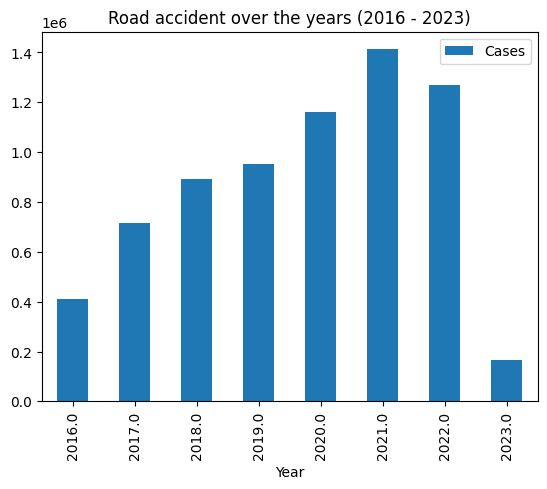

In [28]:
year_df.plot(
    kind = 'bar',
    x = 'Year',
    y = 'Cases',
    title = 'Road accident over the years (2016 - 2023)'
)

In [29]:
for _,row in year_df.iterrows():
    print(row['Year'], round(row['Cases'] * 100 / sum(year_df.Cases),2))

2016.0 5.88
2017.0 10.27
2018.0 12.79
2019.0 13.66
2020.0 16.63
2021.0 20.22
2022.0 18.16
2023.0 2.38


In [30]:
year_df.describe()

,Year,Cases
count,8.00000,8.000000e+00
mean,2019.50000,8.731535e+05
std,2.44949,4.267636e+05
min,2016.00000,1.665520e+05
25%,2017.75000,6.406728e+05
50%,2019.50000,9.238640e+05
75%,2021.25000,1.188400e+06
max,2023.00000,1.412433e+06


<p>Accidents was on the rise until 2023
<p>2022 was the most accident prone year with 22.8% of 7 years

## Day

In [31]:
day_df = pd.DataFrame(
    df.Start_Time
    .dt
    .day_name()
    .value_counts(ascending=False)
    ).reset_index().rename(columns={'Start_Time': 'Day','count': 'Cases'})
day_df.head(10)

,Day,Cases
0,Friday,1237229
1,Thursday,1196137
2,Wednesday,1195864
3,Tuesday,1177923
4,Monday,1108807
5,Saturday,579153
6,Sunday,490115


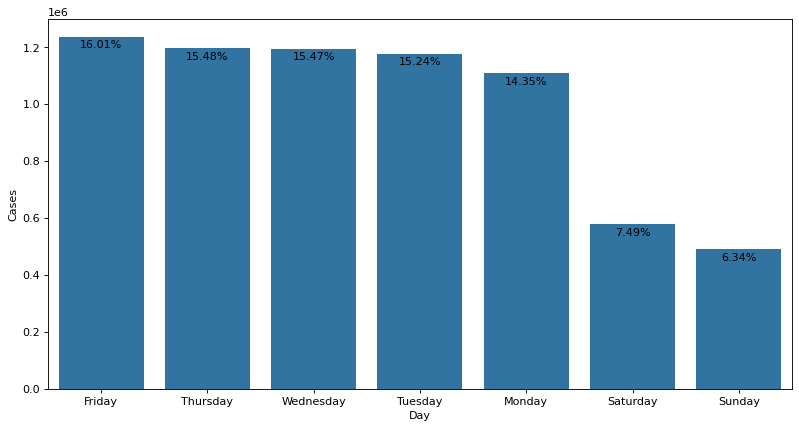

In [32]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)
ax = sns.barplot(
    x = day_df.Day,
    y = day_df.Cases
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height() - 40000,
        f'{round(i.get_height()*100/df.shape[0],2)}%',
        ha = 'center'
    )

In [33]:
days_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

round(day_df[day_df['Day'].isin(days_order[:4])]['Cases'].sum()
      *100 /
      day_df[day_df['Day'].isin(days_order[-2:])]['Cases'].sum()
      ,2
      )

np.float64(437.56)

<p>Working days accounted for 66.38% of all accidents, over 4 times during the weekends
<p>Only 15.93% of accidents recorded during the weekend
<p>Friday have the highest percentage of road accidents (17.68%)
<p>Sunday is the lowest (7.28%)

## Hour

In [34]:
hour_df = pd.DataFrame(
    df['Start_Time']
    .dt
    .hour
    .value_counts()
).reset_index().rename(
    columns = {
        'Start_Time': 'Hour',
        'count': 'Cases'
    }
)
hour_df.head()

,Hour,Cases
0,7.0,546789
1,8.0,541643
2,16.0,520177
3,17.0,516626
4,15.0,463389


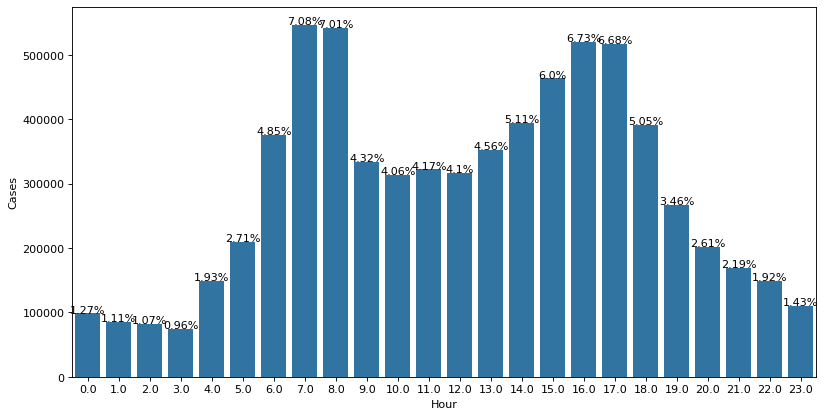

In [35]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = hour_df,
    x = 'Hour',
    y = 'Cases'
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width() / 2,
        i.get_height()+1000,
        str(round(i.get_height()*100/df.shape[0],2))+'%',
        fontsize = 10,
        ha = 'center',
        color = 'black'
    )

<p>20.32% of road accidents happen during 6:00-8:00
<p>27.37% of road accidents happen during 15:00 - 18:00
<p>Deadliest hours being 7:00-8:00 and 16:00-17:00 implies the rush hours of arriving and returning. Accounted for 30.05% of all accidents

## Road Condition

In [36]:
df[df.columns[-16:-4]].head()

,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


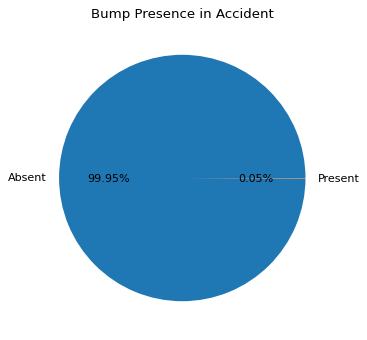

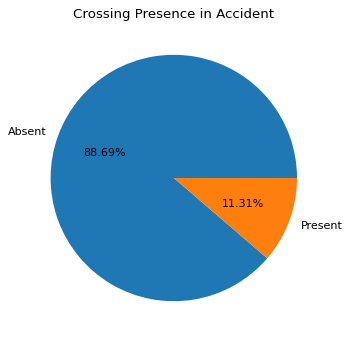

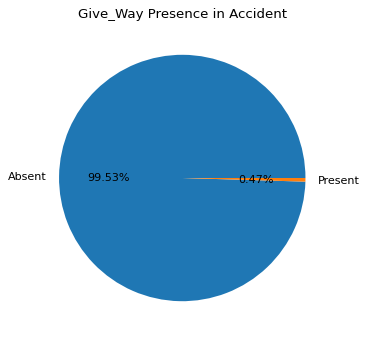

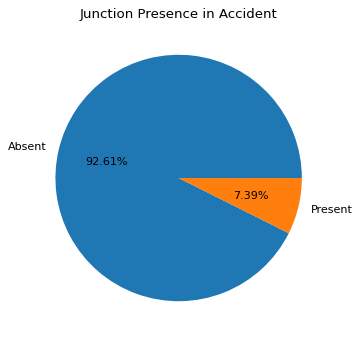

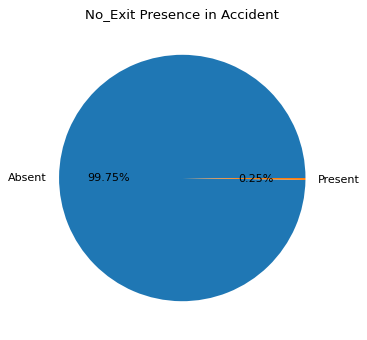

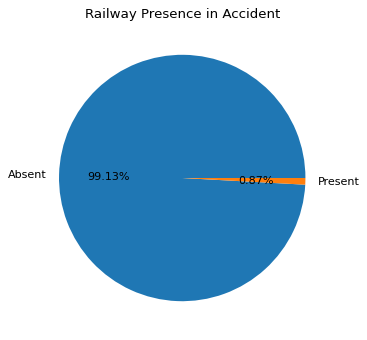

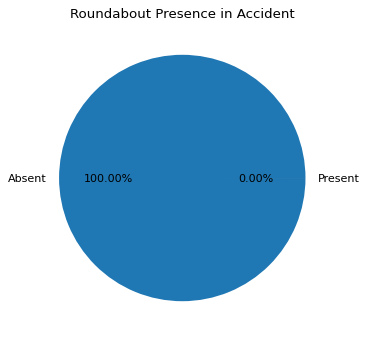

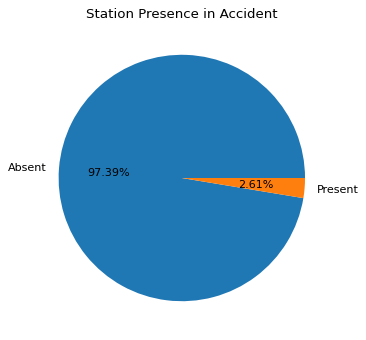

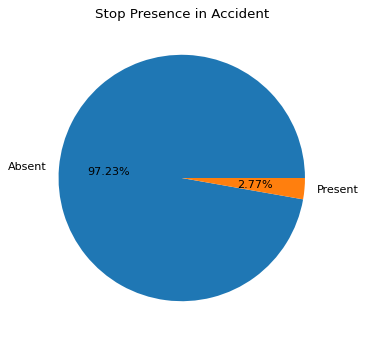

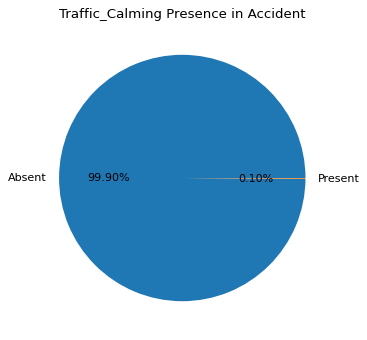

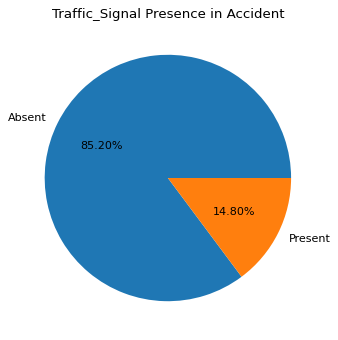

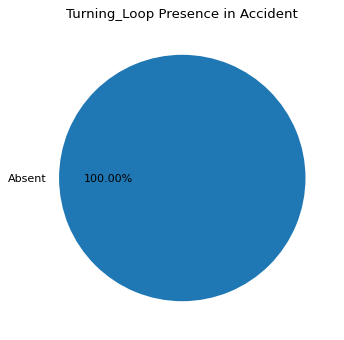

In [37]:
features = [
    'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station',
    'Stop', 'Traffic_Calming', 'Traffic_Signal',
    'Turning_Loop'
]
for i in features:
    counts = df[i].value_counts()

    labels = counts.index.map({
        False: 'Absent',
        True: 'Present'
    })

    plt.figure(
        figsize = (5,5),
        dpi=80
    )
    plt.pie(
        counts,
        labels = labels,
        autopct = '%.2f%%',
        # title = i + 'presence in Accidents'
    )
    plt.title(f'{i} Presence in Accident')
    plt.show()

<p> 100% of accidents lack the presence of Turning loop and Roundabout
<p> The most ineffective accident prevention is Traffic light with 14.8% of accident happen in its presence
<p>Bump, Give way, No Exit sign, Traffic Calming was absent in almost every case

In [38]:
df[df.columns[20:29]].head()
# df['Weather_Timestamp'].head()20:29

,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition
0,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain
1,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain
2,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast
3,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy
4,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy


In [39]:
df['Weather_Condition'].unique()

<StringArray>
[               'Light Rain',                  'Overcast',
             'Mostly Cloudy',                      'Rain',
                'Light Snow',                      'Haze',
          'Scattered Clouds',             'Partly Cloudy',
                     'Clear',                      'Snow',
 ...
   'Heavy Sleet and Thunder',     'Drifting Snow / Windy',
       'Shallow Fog / Windy',  'Thunder and Hail / Windy',
       'Heavy Sleet / Windy',              'Sand / Windy',
 'Heavy Rain Shower / Windy',       'Blowing Snow Nearby',
         'Heavy Rain Shower',             'Drifting Snow']
Length: 145, dtype: str

In [40]:
condition_df = pd.DataFrame(
    df.Weather_Condition
    .value_counts()
    ).reset_index().rename(
        columns={
            'count':'Cases'
        }
    )

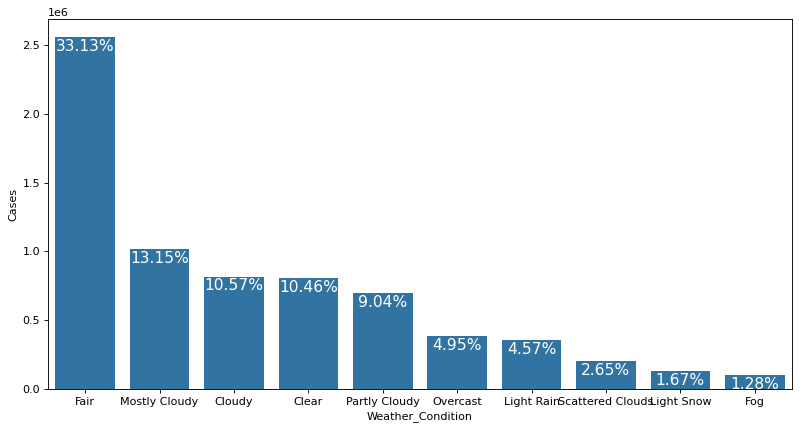

In [41]:
fig, ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = condition_df.head(10),
    x = 'Weather_Condition',
    y = 'Cases',
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height() - 100000,
        str(round(i.get_height() * 100 / df.shape[0],2)) + '%',
        fontsize = 14,
        color = 'white',
        ha = 'center'
    )

In [42]:
def make_bins(attribute, gap):
    min_val = int(attribute.min())
    max_val = int(attribute.max())

    bins = list(range(min_val, max_val + gap, gap))

    labels = [
        f'{bins[i]}:{bins[i+1]}'
        for i in range(len(bins)-1)
    ]

    grouped = pd.cut(
        attribute,
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    grouped_df = (
        grouped
        .value_counts()
        .sort_index()
        .reset_index()
    )

    grouped_df.columns = ['Range', 'Cases']

    return grouped_df

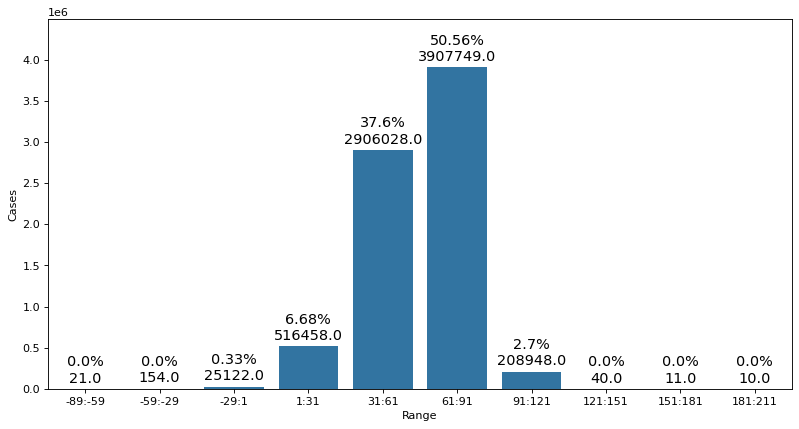

In [43]:
temp_df = make_bins(df['Temperature(F)'],30)
temp_df = temp_df.rename(columns={
        'count': 'Cases'
    }
)

fig,ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax = sns.barplot(
    data = temp_df,
    x = 'Range',
    y = 'Cases'
)

ax.set_ylim(
    0,
    max(temp_df['Cases']) * 1.15
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height()+ (max(temp_df.Cases) * 0.02),
        f'{round(i.get_height() * 100 / df.shape[0],2)}%\n{i.get_height()}',
        color = 'black',
        ha = 'center',
        fontsize = 13
    )

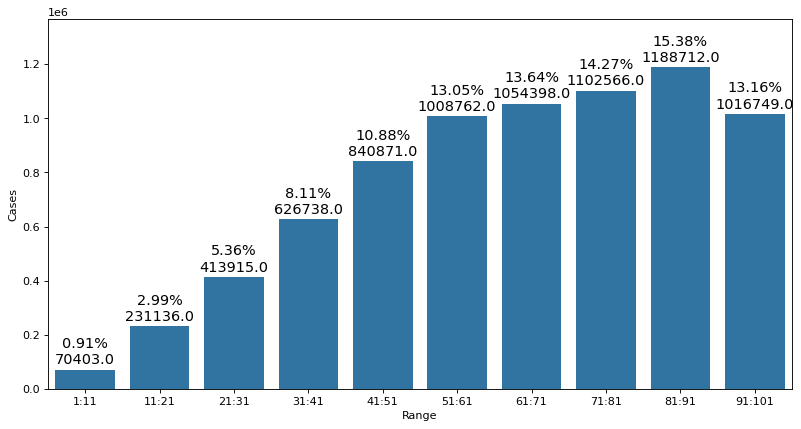

In [44]:
humid_df = make_bins(df['Humidity(%)'],10)
humid_df = humid_df.rename(
    columns = {
        'count': 'Cases'
    }
)

fig,ax = plt.subplots(
    figsize = (12,6),
    dpi = 80
)

ax.set_ylim(
    0,
    max(humid_df['Cases']) * 1.15
)

ax = sns.barplot(
    data = humid_df,
    x = 'Range',
    y = 'Cases'
)

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height()+20000,
        f'{round(i.get_height() * 100 / df.shape[0],2)}%\n{i.get_height()}',
        color = 'black',
        ha = 'center',
        fontsize = 13
    )

In [45]:
def sns_barplot(data,title):

    fig, ax = plt.subplots(
        figsize=(12,6),
        dpi=80
    )

    ax = sns.barplot(
        data=data,
        x= 'Range',
        y= 'Cases'
    )

    ax.set_ylim(
        0,
        max(data['Cases']) * 1.15
    )

    ax.set_title(
        title,
        fontsize = 18
    )

    for i in ax.patches:

        ax.text(
            i.get_x() + i.get_width()/2,

            i.get_height() + (max(data['Cases']) * 0.02),

            f'{i.get_height() * 100 / df.shape[0]:.2f}%\n{int(i.get_height()):,}',

            color='black',
            ha='center',
            fontsize=13
        )

    plt.show()

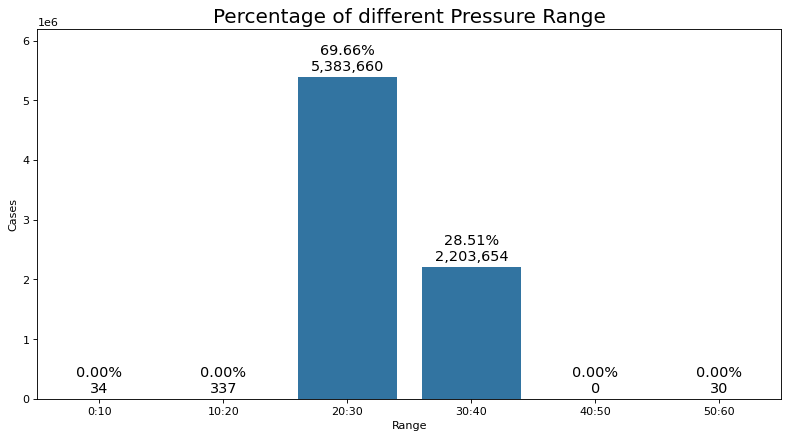

In [46]:
pressure_df = make_bins(df['Pressure(in)'],10)
pressure_df
sns_barplot(pressure_df,'Percentage of different Pressure Range')

In [47]:
# series = pd.to_numeric(df['Wind_Speed(mph)'], errors = 'coerce')
# max_val = series.max()
# max_val
df['Wind_Speed(mph)'].max()

np.float64(1087.0)

In [48]:
df['Wind_Speed(mph)'].isna().mean() * 100

np.float64(7.391354529802699)

In [49]:
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(-1)

In [50]:
wind_speed_bin = pd.cut(
    df['Wind_Speed(mph)'],
    bins = [-1,0, 1, 12, 24, 38, max(df['Wind_Speed(mph)'])+0.01],
    labels = [
        'Missing Value',
        'Level 0',
        'Level 1-3',
        'Level 3-5',
        'Level 5-7',
        'Why?'
    ]
)

wind_speed_df = wind_speed_bin.value_counts().reset_index()
wind_speed_df.columns = ['Range', 'Cases']
wind_speed_df['Range'] = pd.Categorical(
    wind_speed_df['Range'],
    categories=[
        'Missing Value',
        'Level 0',
        'Level 1-3',
        'Level 3-5',
        'Level 5-7',
        'Why?'
    ],
    ordered=True
)
wind_speed_df = wind_speed_df.sort_values('Range')
wind_speed_df

,Range,Cases
2,Missing Value,961643
5,Level 0,195
0,Level 1-3,4908411
1,Level 3-5,1241741
3,Level 5-7,43747
4,Why?,1424


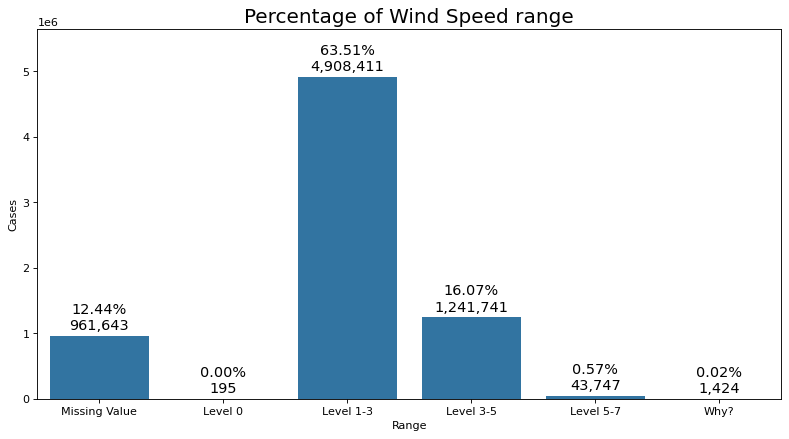

In [51]:
sns_barplot(wind_speed_df,'Percentage of Wind Speed range')

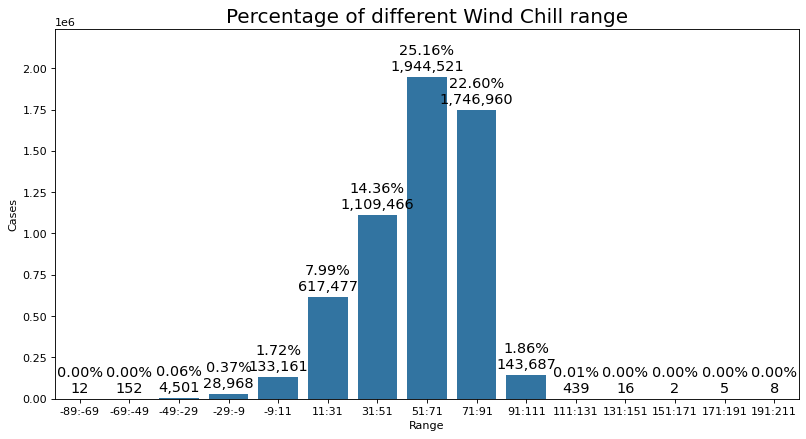

In [52]:
wind_chill_df = make_bins(df['Wind_Chill(F)'], 20)
sns_barplot(wind_chill_df,'Percentage of different Wind Chill range')

In [53]:
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(-1)

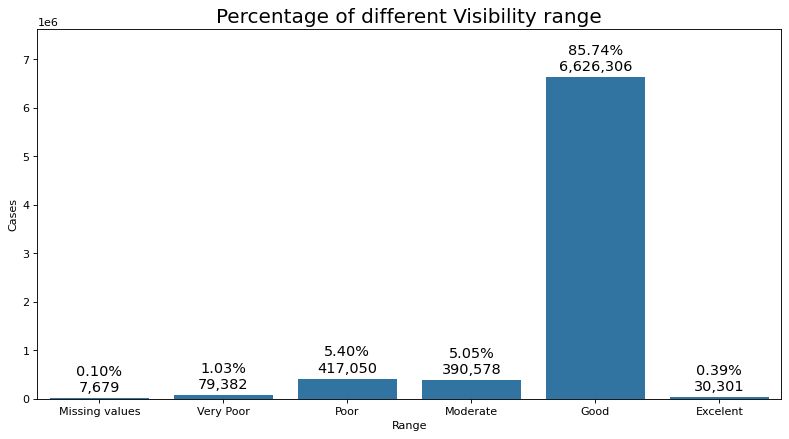

In [54]:
visi_bin = pd.cut(
    df['Visibility(mi)'],
    bins = [-1,0,0.6,3.1,6.2,12.4,max(df['Visibility(mi)'])],
    labels = [
        'Missing values',
        'Very Poor',
        'Poor',
        'Moderate',
        'Good',
        'Excelent'
    ],
    ordered=True
)
visi_df = visi_bin.value_counts().reset_index()
visi_df.columns = ['Range', 'Cases']
visi_df = visi_df.sort_values('Range')

sns_barplot(visi_df,'Percentage of different Visibility range')

## Correlations with Severity

In [13]:
df_anal = df
df_anal.shape

(7728394, 46)

In [56]:
df_anal.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [57]:
df_anal['Duration'] = df.End_Time - df.Start_Time
df_anal['Duration_min'] = (df_anal.Duration.dt.total_seconds() / 60)
max_val = df_anal['Duration_min'].max()
max_val

np.float64(2812939.0)

In [58]:
pd.options.display.float_format = '{:.0f}'.format
df_anal.loc[df_anal['Severity'] == 4, 'Duration_min'].describe()

count    184729
mean       1634
std       27118
min           7
25%          45
50%         130
75%         360
max     1579259
Name: Duration_min, dtype: float64

<Axes: >

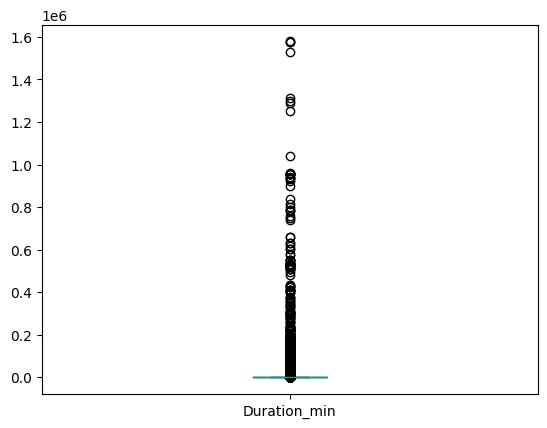

In [59]:
df_anal.loc[df_anal['Severity'] == 4, 'Duration_min'].plot(
    kind = 'box',
    x = 'Severity',
    y = 'Duration_min'
)

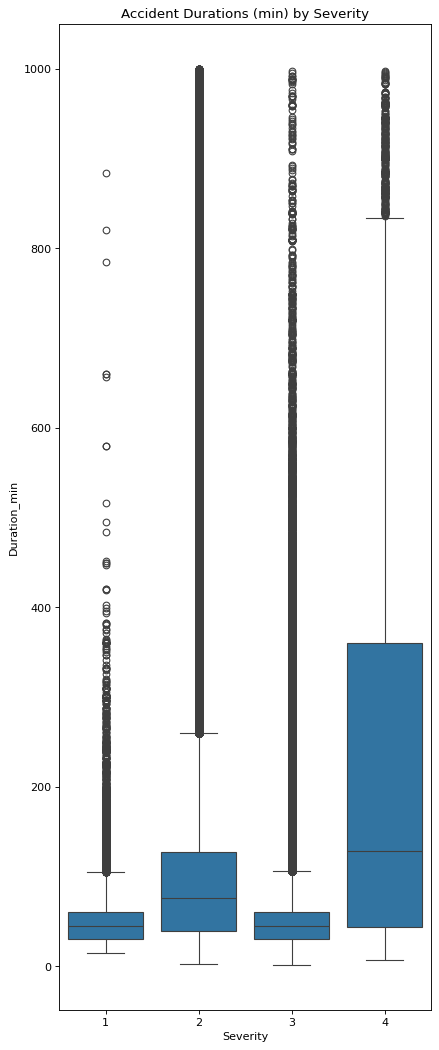

In [60]:
fig,ax = plt.subplots(
    figsize = (6,16),
    dpi = 80
)

ax = sns.boxplot(
    data = df_anal.loc[df_anal['Duration_min']<1000],
    x = 'Severity',
    y = 'Duration_min'
)

ax.set_title('Accident Durations (min) by Severity')

plt.show()

In [61]:
df_anal['Distance(mi)'].describe()

count   7728394
mean          1
std           2
min           0
25%           0
50%           0
75%           0
max         442
Name: Distance(mi), dtype: float64

<Axes: >

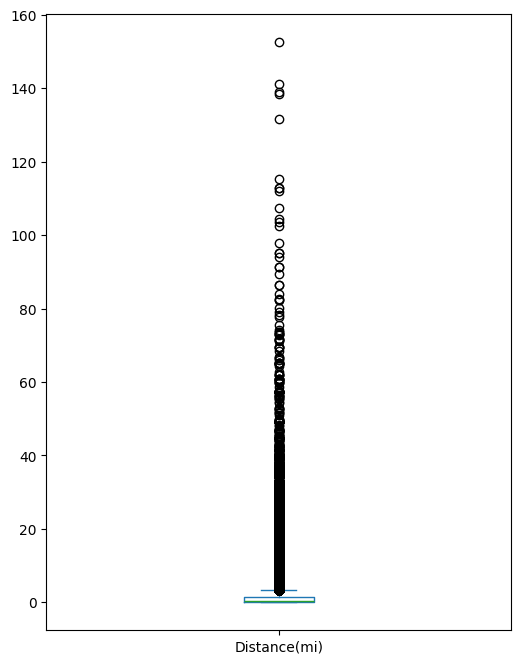

In [62]:
df_anal.loc[df_anal['Severity'] == 4, 'Distance(mi)'].plot(
    kind = 'box',
    x = 'Severity',
    y = 'Distance(mi)',
    figsize = (6,8)
)

Text(0.5, 1.0, 'Impacted Distance (miles) by Severity')

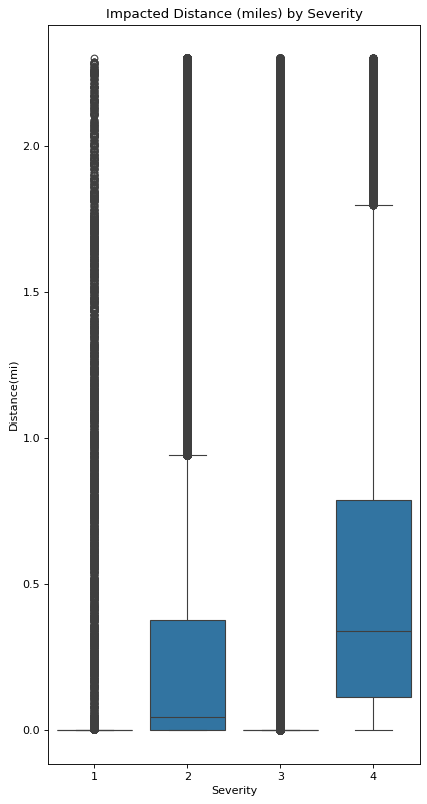

In [63]:
fig, ax =plt.subplots(
    figsize = (6,12),
    dpi = 80
)

ax = sns.boxplot(
    data = df_anal.loc[df_anal['Distance(mi)'] < 2.3],
    x = 'Severity',
    y = 'Distance(mi)'
)

ax.set_title('Impacted Distance (miles) by Severity')

## CLean

In [3]:
feature_lst=['Severity','Distance(mi)','Temperature(F)','Humidity(%)','Pressure(in)', 'Visibility(mi)', 'Wind_Direction','Weather_Condition','Amenity','Bump','Crossing','Give_Way','Junction','No_Exit','Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop','Sunrise_Sunset']
df_anal = df[feature_lst].copy()
df_anal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 22 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Distance(mi)       float64
 2   Temperature(F)     float64
 3   Humidity(%)        float64
 4   Pressure(in)       float64
 5   Visibility(mi)     float64
 6   Wind_Direction     str    
 7   Weather_Condition  str    
 8   Amenity            bool   
 9   Bump               bool   
 10  Crossing           bool   
 11  Give_Way           bool   
 12  Junction           bool   
 13  No_Exit            bool   
 14  Railway            bool   
 15  Roundabout         bool   
 16  Station            bool   
 17  Stop               bool   
 18  Traffic_Calming    bool   
 19  Traffic_Signal     bool   
 20  Turning_Loop       bool   
 21  Sunrise_Sunset     str    
dtypes: bool(13), float64(5), int64(1), str(3)
memory usage: 626.5 MB


In [4]:
df_anal = df_anal.drop('Turning_Loop',axis = 1)

In [5]:
df_anal.columns

Index(['Severity', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Weather_Condition',
       'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
       'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
       'Traffic_Signal', 'Sunrise_Sunset'],
      dtype='str')

In [6]:
df_anal['Wind_Direction'].unique()

<StringArray>
[    'Calm',       'SW',      'SSW',      'WSW',      'WNW',       'NW',
     'West',      'NNW',      'NNE',    'South',    'North', 'Variable',
       'SE',      'SSE',      'ESE',     'East',       'NE',      'ENE',
        'E',        'W',        nan,        'S',      'VAR',     'CALM',
        'N']
Length: 25, dtype: str

In [7]:
df_anal.loc[
    df_anal['Wind_Direction'].isin(
        ['West','WSW','WNW']
    ), 'Wind_Direction'
] = 'W'

df_anal.loc[
    df_anal['Wind_Direction'].isin(
        ['South', 'SSE', 'SSW']
    ), 'Wind_Direction'
    ] = 'S'

df_anal.loc[
    df_anal['Wind_Direction'].isin(
        ['North', 'NNW', 'NNE']
    ), 'Wind_Direction'
] = 'N'

df_anal.loc[
    df_anal['Wind_Direction'].isin(
        ['East', 'ESE', 'ENE']
    ), 'Wind_Direction'
] = 'E'

df_anal.loc[
    df_anal['Wind_Direction'] == 'Variable',
    'Wind_Direction'
] = 'VAR'

df_anal.loc[
    df_anal['Wind_Direction'] == 'Calm',
    'Wind_Direction'
] = 'CALM'

df_anal.Wind_Direction.unique()

<StringArray>
['CALM', 'SW', 'S', 'W', 'NW', 'N', 'VAR', 'SE', 'E', 'NE', nan]
Length: 11, dtype: str

In [8]:
for i in df_anal['Weather_Condition'].unique():
    print(i)

Light Rain
Overcast
Mostly Cloudy
Rain
Light Snow
Haze
Scattered Clouds
Partly Cloudy
Clear
Snow
Light Freezing Drizzle
Light Drizzle
Fog
Shallow Fog
Heavy Rain
Light Freezing Rain
Cloudy
Drizzle
nan
Light Rain Showers
Mist
Smoke
Patches of Fog
Light Freezing Fog
Light Haze
Light Thunderstorms and Rain
Thunderstorms and Rain
Fair
Volcanic Ash
Blowing Sand
Blowing Dust / Windy
Widespread Dust
Fair / Windy
Rain Showers
Mostly Cloudy / Windy
Light Rain / Windy
Hail
Heavy Drizzle
Showers in the Vicinity
Thunderstorm
Light Rain Shower
Light Rain with Thunder
Partly Cloudy / Windy
Thunder in the Vicinity
T-Storm
Heavy Thunderstorms and Rain
Thunder
Heavy T-Storm
Funnel Cloud
Heavy T-Storm / Windy
Blowing Snow
Light Thunderstorms and Snow
Heavy Snow
Low Drifting Snow
Light Ice Pellets
Ice Pellets
Squalls
N/A Precipitation
Cloudy / Windy
Light Fog
Sand
Snow Grains
Snow Showers
Heavy Thunderstorms and Snow
Rain / Windy
Heavy Rain / Windy
Heavy Ice Pellets
Light Snow / Windy
Heavy Freezing Rain


In [9]:
def weather_category(x):

    if pd.isna(x):
        return 'Unknown'

    x = x.lower()

    if 'heavy snow' in x:
        return 'Heavy_Snow'

    elif 'snow' in x or 'sleet' in x or 'ice pellets' in x:
        return 'Snow'

    elif 'heavy rain' in x or 'thunderstorm' in x:
        return 'Heavy_Rain'

    elif 'rain' in x or 'drizzle' in x or 'shower' in x:
        return 'Rain'

    elif 'fog' in x or 'mist' in x or 'haze' in x:
        return 'Fog'

    elif (
        'cloud' in x
        or 'overcast' in x
        or 'fair' in x
        or 'scattered clouds' in x
    ):
        return 'Cloud'

    elif 'clear' in x:
        return 'Clear'

    else:
        return 'Other'

In [10]:
df_anal['Weather_Category'] = df_anal['Weather_Condition'].apply(weather_category)
df_anal.drop('Weather_Condition', axis = 1)

,Severity,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Amenity,Bump,Crossing,...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Weather_Category
0,3,0.010,36.9,91.0,29.68,10.0,CALM,False,False,False,...,False,False,False,False,False,False,False,False,Night,Rain
1,2,0.010,37.9,100.0,29.65,10.0,CALM,False,False,False,...,False,False,False,False,False,False,False,False,Night,Rain
2,2,0.010,36.0,100.0,29.67,10.0,SW,False,False,False,...,False,False,False,False,False,False,False,True,Night,Cloud
3,3,0.010,35.1,96.0,29.64,9.0,SW,False,False,False,...,False,False,False,False,False,False,False,False,Night,Cloud
4,2,0.010,36.0,89.0,29.65,6.0,SW,False,False,False,...,False,False,False,False,False,False,False,True,Day,Cloud
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,2,0.543,86.0,40.0,28.92,10.0,W,False,False,False,...,False,False,False,False,False,False,False,False,Day,Cloud
7728390,2,0.338,70.0,73.0,29.39,10.0,SW,False,False,False,...,False,False,False,False,False,False,False,False,Day,Cloud
7728391,2,0.561,73.0,64.0,29.74,10.0,S,False,False,False,...,True,False,False,False,False,False,False,False,Day,Cloud
7728392,2,0.772,71.0,81.0,29.62,10.0,SW,False,False,False,...,False,False,False,False,False,False,False,False,Day,Cloud


In [13]:
df_anal['Month'] = df['Start_Time'].dt.month

df_anal['Hour'] = df['Start_Time'].dt.hour

df_anal['Is_Weekday'] = (
    df['Start_Time']
    .dt.dayofweek < 5
)

df_anal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 25 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Distance(mi)       float64
 2   Temperature(F)     float64
 3   Humidity(%)        float64
 4   Pressure(in)       float64
 5   Visibility(mi)     float64
 6   Wind_Direction     str    
 7   Weather_Condition  str    
 8   Amenity            bool   
 9   Bump               bool   
 10  Crossing           bool   
 11  Give_Way           bool   
 12  Junction           bool   
 13  No_Exit            bool   
 14  Railway            bool   
 15  Roundabout         bool   
 16  Station            bool   
 17  Stop               bool   
 18  Traffic_Calming    bool   
 19  Traffic_Signal     bool   
 20  Sunrise_Sunset     str    
 21  Weather_Category   str    
 22  Month              float64
 23  Hour               float64
 24  Is_Weekday         bool   
dtypes: bool(13), float64(7), int6

In [14]:
df['Street'].unique()

<StringArray>
[                   'I-70 E',                  'Brice Rd',
            'State Route 32',                    'I-75 S',
 'Miamisburg Centerville Rd',            'Westerville Rd',
            'N Woodward Ave',                 'N Main St',
            'Notre Dame Ave',               'Outerbelt S',
 ...
                ' W Arch St',                 ' Sheep Ln',
   ' Marys River Estates Rd',                   ' M 65 S',
              ' Lippoldt Rd',           ' Darden Farm Ln',
              ' Bushnell St',             ' N Digital Dr',
            ' San Marlo Way',         '473-401 Cutoff Rd']
Length: 336307, dtype: str

In [15]:
import re

tokens = []

for street in df['Street'].dropna():

    split_words = re.split(r'[\s\-]+', street)
    ignore = ['n','s','e','w']

    filtered_words = [
        word.lower()
        for word in split_words
        if (
            word.isalpha()
            and word.lower() not in ignore
        )
    ]

    tokens.extend(filtered_words)

In [16]:
token_df = pd.Series(tokens).value_counts()
token_df.head(40)

i           1927555
rd          1159602
st           684191
ave          640512
blvd         343949
fwy          330007
dr           327053
highway      303837
us           290677
hwy          259602
ca           256693
pkwy         190444
state        183358
expy         145873
sw           105839
nw           104470
ln            93421
ga            74827
tpke          72382
ne            64986
route         53210
pike          51838
old           46661
new           45080
road          44757
memorial      43912
lake          42129
river         41536
way           41353
main          38895
valley        38744
capital       38423
se            37937
beltway       37002
trl           35399
san           33624
creek         33165
john          32632
ct            31180
loop          30288
Name: count, dtype: int64

In [17]:
df['street_lower'] = df['Street'].str.lower()

df_anal['is_freeway'] = (
    df['street_lower']
    .str.contains(
        r'\b(?:i|fwy|hwy|highway|route|tpke|beltway)\b',
        na=False
    )
)

df_anal['urban_road'] = (
    df['street_lower']
    .str.contains(
        r'\b(?:st|street|ave|avenue|rd|road|dr|drive|ln|lane|blvd|boulevard)\b',
        na=False
    )
)

df_anal['special_road'] = (
    df['street_lower']
    .str.contains(
        r'\b(?:pkwy|parkway|expy|expressway|loop|trl|trail|pike)\b',
        na=False
    )
)

df_anal['other_road'] = ~(
    df_anal['is_freeway']
    | df_anal['urban_road']
    | df_anal['special_road']
)

In [18]:
print(
    pd.concat(
        [
            df['Street'].head(30),
            df_anal[
                [
                    'is_freeway',
                    'urban_road',
                    'special_road',
                    'other_road'
                ]
            ].head(30)
        ],
        axis=1
    )
)

                       Street  is_freeway  urban_road  special_road  \
0                      I-70 E        True       False         False   
1                    Brice Rd       False        True         False   
2              State Route 32        True       False         False   
3                      I-75 S        True       False         False   
4   Miamisburg Centerville Rd       False        True         False   
5              Westerville Rd       False        True         False   
6              N Woodward Ave       False        True         False   
7                   N Main St       False        True         False   
8              Notre Dame Ave       False        True         False   
9              Westerville Rd       False        True         False   
10                Outerbelt S       False       False         False   
11                     I-70 E        True       False         False   
12             Watervliet Ave       False        True         False   
13    

In [19]:
import numpy as np

conditions = [
    df_anal['is_freeway'],
    df_anal['urban_road'],
    df_anal['special_road'],
    df_anal['other_road']
]

choices = [
    'freeway',
    'urban',
    'special',
    'other'
]

df_anal['road_type'] = np.select(
    conditions,
    choices,
    default='unknown'
)

In [20]:
df_anal = df_anal.drop([
    'is_freeway',
    'urban_road',
    'special_road',
    'other_road'
], axis = 1
)

In [21]:
df_anal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 26 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Distance(mi)       float64
 2   Temperature(F)     float64
 3   Humidity(%)        float64
 4   Pressure(in)       float64
 5   Visibility(mi)     float64
 6   Wind_Direction     str    
 7   Weather_Condition  str    
 8   Amenity            bool   
 9   Bump               bool   
 10  Crossing           bool   
 11  Give_Way           bool   
 12  Junction           bool   
 13  No_Exit            bool   
 14  Railway            bool   
 15  Roundabout         bool   
 16  Station            bool   
 17  Stop               bool   
 18  Traffic_Calming    bool   
 19  Traffic_Signal     bool   
 20  Sunrise_Sunset     str    
 21  Weather_Category   str    
 22  Month              float64
 23  Hour               float64
 24  Is_Weekday         bool   
 25  road_type          str    
dt

In [33]:
missing = (
    pd.DataFrame(
        df_anal.isnull().sum(),
        columns=['Missing_Count']
    )
    .reset_index()
    .rename(columns={'index':'Feature'})
)

missing['Missing_Percent(%)'] = round(
    missing['Missing_Count'] / len(df_anal) * 100,
    2
)

missing = missing.loc[
    missing['Missing_Count'] > 0
]

print(missing)

Empty DataFrame
Columns: [Feature, Missing_Count, Missing_Percent(%)]
Index: []


In [24]:
df_anal.Hour.unique()

array([ 5.,  6.,  7.,  8.,  9., 10., 11., 12., 14., 15., 16., 17., 18.,
       19., 20.,  4., 13., 23., 21., 22.,  0.,  1.,  2.,  3., nan])

In [25]:
df_anal.loc[
    df_anal['Sunrise_Sunset'].isna() & df_anal['Hour'].between(6,18),
    'Sunrise_Sunset'
] = 'Day'

df_anal.loc[
    df_anal['Sunrise_Sunset'].isna() & ~df_anal['Hour'].between(6,18),
    'Sunrise_Sunset'
] = 'Night'

In [26]:
num_cols = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)'
]

for col in num_cols:

    df_anal[col] = (
        df_anal[col]
        .fillna(df_anal[col].median())
    )

In [ ]:
df_anal['Visibility(mi)'] = df_anal['Visibility(mi)'].fillna(df_anal['Visibility(mi)'].median())

In [30]:
cat_cols = [
    'Wind_Direction',
    'Weather_Condition'
]

for col in cat_cols:

    df_anal[col] = (
        df_anal[col]
        .fillna('Unknown')
    )

In [32]:
df_anal['Month'] = (
    df['Start_Time']
    .dt.month
    .fillna(0)
    .astype(int)
)

df_anal['Hour'] = (
    df['Start_Time']
    .dt.hour
    .fillna(-1)
    .astype(int)
)

df_anal['Month'] = df_anal['Month'].astype(str)
df_anal['Hour'] = df_anal['Hour'].astype(str)

## Piercé de Resistancé

In [83]:
X = df_anal.drop(columns=['Severity'])
y = df_anal['Severity']

In [ ]:
cat_cols = [
    'Wind_Direction',
    'Weather_Condition',
    'Sunrise_Sunset',
    'Weather_Category',
    'road_type',
    'Hour',
    'Month'
]

num_cols = [
    'Distance(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)'
]

bool_cols = [
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Is_Weekday'
]

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [86]:
preprocess = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        ),

        (
            'num',
            StandardScaler(),
            num_cols
        ),

        (
            'bool',
            'passthrough',
            bool_cols
        )
    ]
)

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Logistic Regression Model

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [89]:
log_model = Pipeline(
    steps=[
        ('preprocess', preprocess),

        (
            'model',
            LogisticRegression(
                max_iter=1000,
                # multi_class='multinomial',
                class_weight='balanced',
                n_jobs=-1
            )
        )
    ]
)

In [90]:
# import sklearn
# print(sklearn.__version__)

In [91]:
# from sklearn.linear_model import LogisticRegression

# print(LogisticRegression)

In [92]:
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

c:\Users\FannyBandit\Documents\DSclass\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [93]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(classification_report(y_test, y_pred))

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred), 4)
)

              precision    recall  f1-score   support

           1       0.03      0.79      0.06     13074
           2       0.89      0.29      0.44   1049428
           3       0.35      0.60      0.44    251464
           4       0.06      0.38      0.10     34921

    accuracy                           0.36   1348887
   macro avg       0.33      0.52      0.26   1348887
weighted avg       0.76      0.36      0.43   1348887

Accuracy: 0.3555


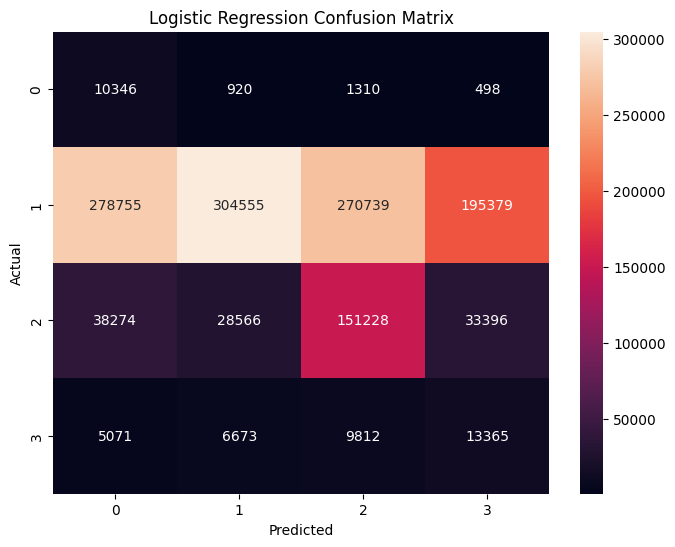

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### KN Neighbours

In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [96]:
knn_model = Pipeline(
    steps=[
        ('preprocess', preprocess),

        (
            'model',
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

In [ ]:
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('KNN Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
tree_preprocess = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        ),

        (
            'num',
            'passthrough',
            num_cols
        ),

        (
            'bool',
            'passthrough',
            bool_cols
        )
    ]
)

In [ ]:
tree_model = Pipeline(
    steps=[
        ('preprocess', tree_preprocess),

        (
            'model',
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=50,
                random_state=42,
                class_weight='balanced'
            )
        )
    ]
)

In [ ]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [ ]:
y_pred_tree = tree_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(classification_report(
    y_test,
    y_pred_tree
))

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_tree
        ),
        4
    )
)

              precision    recall  f1-score   support

           1       0.05      0.86      0.10     13074
           2       0.93      0.32      0.48   1049428
           3       0.47      0.59      0.52    251464
           4       0.06      0.84      0.12     34921

    accuracy                           0.39   1348887
   macro avg       0.38      0.65      0.30   1348887
weighted avg       0.82      0.39      0.47   1348887

Accuracy: 0.3886


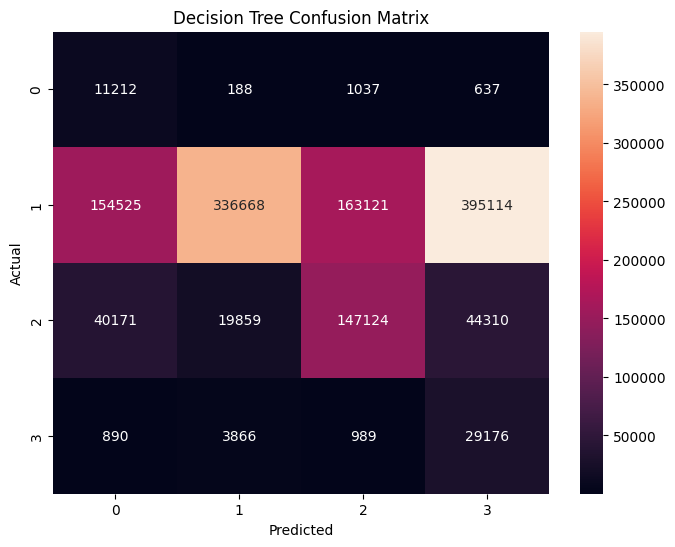

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
model = tree_model.named_steps['model']

encoded_cols = (
    tree_model
    .named_steps['preprocess']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': encoded_cols,
    'Importance': model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

importance_df.head(15)

,Feature,Importance
165,num__Distance(mi),0
170,num__Month,0
161,cat__road_type_freeway,0
153,cat__Weather_Category_Clear,0
96,cat__Weather_Condition_Overcast,0
183,bool__Traffic_Signal,0
168,num__Pressure(in),0
24,cat__Weather_Condition_Fair,0
113,cat__Weather_Condition_Scattered Clouds,0
171,num__Hour,0


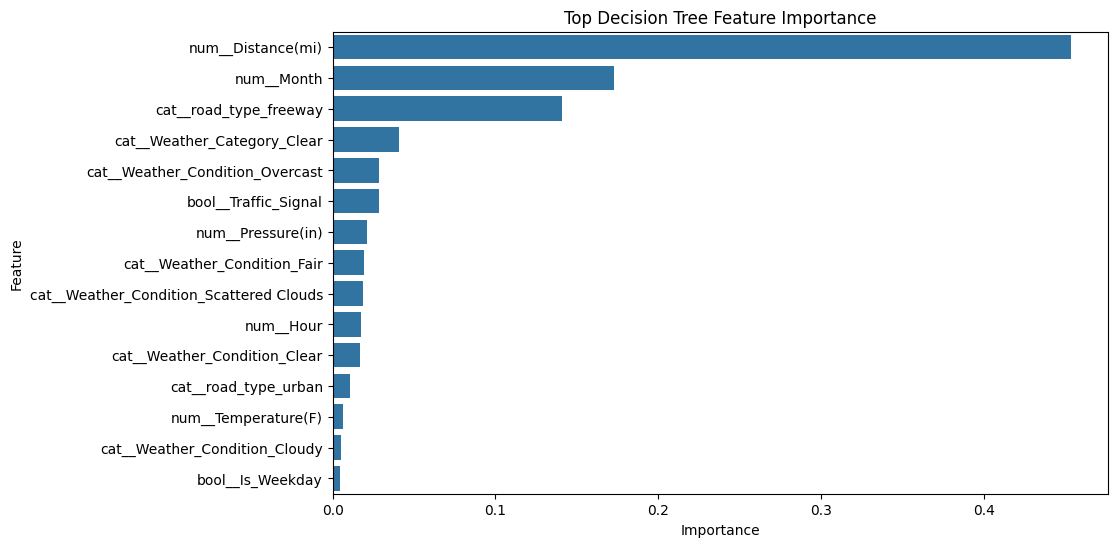

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top Decision Tree Feature Importance')

plt.show()

### Random Forrest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [ ]:
rf_model = Pipeline(
    steps=[
        ('preprocess', tree_preprocess),

        (
            'model',
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=20,
                random_state=42,
                class_weight='balanced',
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(classification_report(
    y_test,
    y_pred_rf
))

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
rf = rf_model.named_steps['model']

feature_names = (
    rf_model
    .named_steps['preprocess']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

importance_df.head(15)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')

plt.show()

### XGBoost - the wonderfully new technology

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = Pipeline(
    steps=[
        ('preprocess', tree_preprocess),

        (
            'model',
            XGBClassifier(
                n_estimators=200,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='multi:softmax',
                num_class=4,
                eval_metric='mlogloss',
                random_state=42
            )
        )
    ]
)

In [ ]:
#remap since xgboost starts at 0
y_xgb = y - 1

In [ ]:
#split again
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

In [ ]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
#evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(classification_report(
    y_test,
    y_pred_xgb
))

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_xgb
        ),
        4
    )
)

              precision    recall  f1-score   support

           0       0.69      0.06      0.12     13062
           1       0.85      0.95      0.89   1046857
           2       0.66      0.45      0.53    250963
           3       0.52      0.05      0.09     34803

    accuracy                           0.82   1345685
   macro avg       0.68      0.38      0.41   1345685
weighted avg       0.80      0.82      0.80   1345685

Accuracy: 0.8215


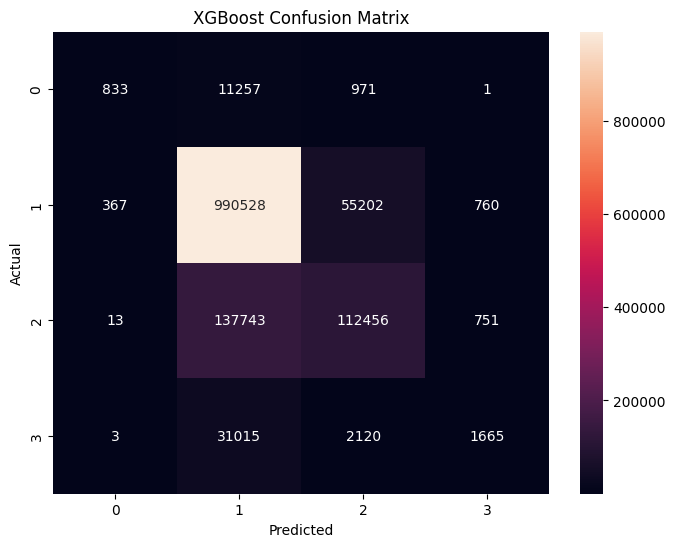

In [ ]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('XGBoost Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
#feature importance
xgb = xgb_model.named_steps['model']

feature_names = (
    xgb_model
    .named_steps['preprocess']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

importance_df.head(15)

,Feature,Importance
158,cat__road_type_freeway,0.208614
162,num__Distance(mi),0.061059
24,cat__Weather_Condition_Fair,0.053197
180,bool__Traffic_Signal,0.050919
94,cat__Weather_Condition_Overcast,0.047275
15,cat__Weather_Condition_Clear,0.045947
161,cat__road_type_urban,0.042943
110,cat__Weather_Condition_Scattered Clouds,0.038723
150,cat__Weather_Category_Clear,0.033399
178,bool__Stop,0.032704


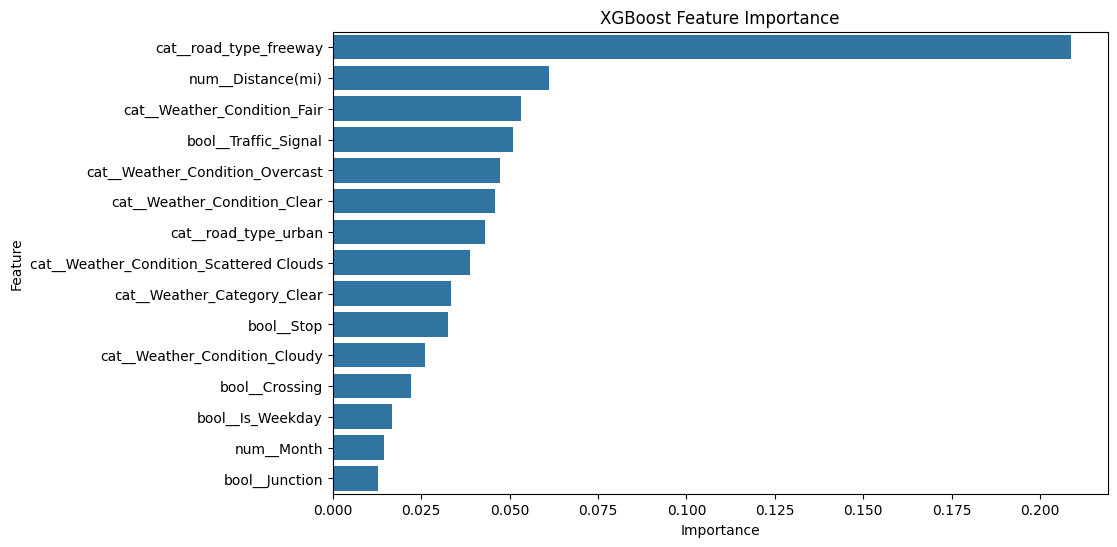

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance')

plt.show()